## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


# 1. Importación de librerías

In [1]:
# Importar librerías de manipulación de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importar herramientas para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Importar kagglehub para descargar el dataset
import kagglehub

# 2. Carga del dataset

In [4]:
# Descargar la última versión del dataset desde Kaggle
path = kagglehub.dataset_download("uciml/adult-census-income")
print("Ruta del dataset:", path)



Ruta del dataset: C:\Users\ferle\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [5]:
# Cargar el archivo CSV
dfAdult = pd.read_csv(path + "/adult.csv")
dfAdult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# 3. Comprensión del problema

In [6]:
# Analizar la distribución de la variable objetivo
print("Distribución de la variable objetivo:")
print(dfAdult["income"].value_counts())

Distribución de la variable objetivo:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


# 4. Exploración inicial (EDA)

In [8]:
# Obtener información general del dataset (tipos de datos, columnas, registros)
dfAdult.info()

# Resumen estadístico de las variables numéricas
dfAdult.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# 5. Correlación e hipótesis

In [9]:
# Como el dataset contiene texto, seleccionamos solo columnas numéricas para la correlación
corr = dfAdult.select_dtypes(include=[np.number]).corr()


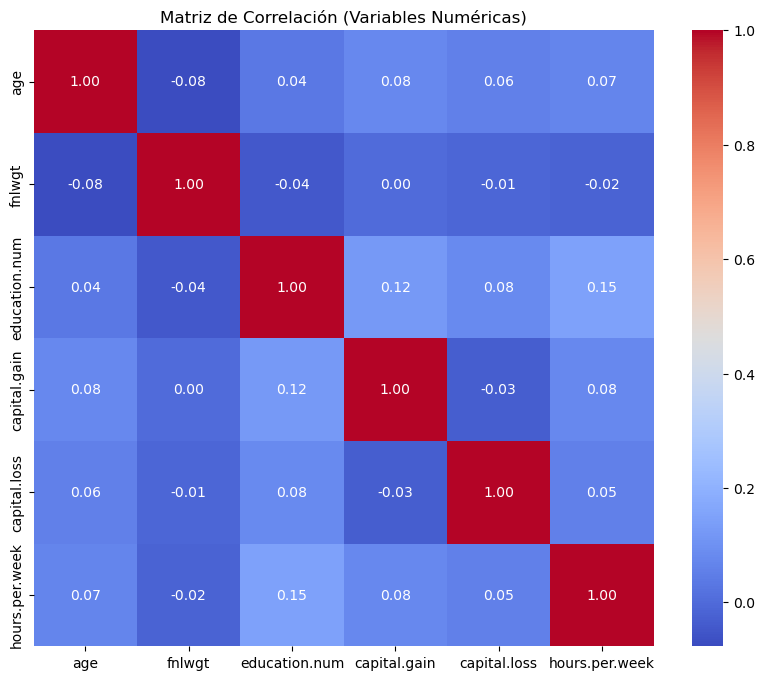

In [10]:
# Graficar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()


In [17]:
# Hipótesis de ejemplo: Agrupamos por ingreso para ver promedios de variables clave
# En el dataset original de Kaggle las columnas son estrictamente en minúsculas y con guion medio
dfAdult.groupby("income")[["age", "hours.per.week"]].mean()

,age,hours.per.week
income,,
<=50K,36.783738,38.840210
>50K,44.249841,45.473026


In [16]:
print(dfAdult.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


# 6. Variables predictoras y objetivo

In [18]:
# Creamos una copia de seguridad para no alterar el DataFrame original
x = dfAdult.drop(columns=["income"]).copy()
y = dfAdult["income"].copy()

# 7. Tratamiento de nulos


In [19]:
# Verificar la presencia de valores nulos
print("Valores nulos por columna:")
print(x.isnull().sum())

Valores nulos por columna:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64


In [20]:
x = x.replace('?', np.nan)

# Rellenar valores nulos numéricos con la mediana y categóricos con la moda (como en Lab 11)
for col in x.columns:
    if x[col].dtype == 'object':
        x[col] = x[col].fillna(x[col].mode()[0])
    else:
        x[col] = x[col].fillna(x[col].median())

# 8. One-Hot Encoding

In [21]:
# Aplicar One-Hot Encoding a las variables categóricas (texto) para convertirlas en numéricas
x = pd.get_dummies(x, drop_first=True)
x.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


# 9. Train/Test Split

In [22]:
# Dividir el dataset en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.20, 
    random_state=42
)

print(f"Registros en entrenamiento: {X_train.shape[0]}")
print(f"Registros en prueba: {X_test.shape[0]}")

Registros en entrenamiento: 26048
Registros en prueba: 6513


# 10. StandardScaler

In [23]:
# Inicializar el escalador de características
scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento, y transformar los datos de prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 11. Árbol de Decisión

In [24]:
# Inicializar el modelo del árbol de decisión para clasificación
modelo = DecisionTreeClassifier(random_state=42, max_depth=10) # max_depth opcional para evitar sobreajuste

# Entrenar el modelo utilizando los datos escalados
modelo.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 12. Predicciones

In [25]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test_scaled)

# 13. Accuracy

In [26]:
# Calcular el porcentaje de predicciones correctas
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8537


# 14. Feature Importance

In [27]:
# Extraer la importancia de cada variable asignada por el árbol de decisión
importancias = pd.DataFrame({
    "Variable": x.columns,
    "Importancia": modelo.feature_importances_
})

# Ordenar de mayor a menor relevancia
importancias.sort_values(by="Importancia", ascending=False).head(10)

,Variable,Importancia
29,marital.status_Married-civ-spouse,0.382211
2,education.num,0.203737
3,capital.gain,0.182187
4,capital.loss,0.067354
0,age,0.051399
5,hours.per.week,0.033924
36,occupation_Exec-managerial,0.014669
1,fnlwgt,0.013586
10,workclass_Self-emp-not-inc,0.005599
42,occupation_Prof-specialty,0.005025
